In [22]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
import pickle
import joblib 
from sklearn.metrics import accuracy_score,roc_auc_score


In [23]:
df = pd.read_csv('../handled/feature_encoded.csv')

In [ ]:
columns = df.columns.tolist()
for col in columns:
    print(f'{col} : {df[col].unique()}')

gender : [1 0]
SeniorCitizen : [0 1]
Partner : [1 0]
Dependents : [1 0]
tenure : [29 58  1 24 72 55 13 67 33 63  3 31 27 52 68 35 66 17 59 61 12 37 64 23
  9  8 15 18 19 51  5 71 60 62 45 69 40 53 54 34  2 70 39 41  4 22 46 28
 42 48 21 43 14 10 47  7 57 36 16 26 20 50 30 11 44 25 56  6 65 38 49 32]
PhoneService : [1 0]
MultipleLines : [0 1]
OnlineSecurity : [1 0]
OnlineBackup : [0 1]
DeviceProtection : [1 0]
TechSupport : [1 0]
StreamingTV : [0 1]
StreamingMovies : [0 1]
PaperlessBilling : [1 0]
MonthlyCharges : [ 60.1   69.5  100.4  ...  45.79  31.5   32.35]
TotalCharges : [1653.85 3778.2  5841.35 ... 4200.35 3230.55 3036.3 ]
Churn : [ 0.  1. nan]
hasInternet : [1 0]
PaymentMethod_Credit card (automatic) : [False  True]
PaymentMethod_Electronic check : [False  True]
PaymentMethod_Mailed check : [ True False]
Contract_One year : [ True False]
Contract_Two year : [False  True]
InternetService_Fiber optic : [False  True]
InternetService_No : [False  True]


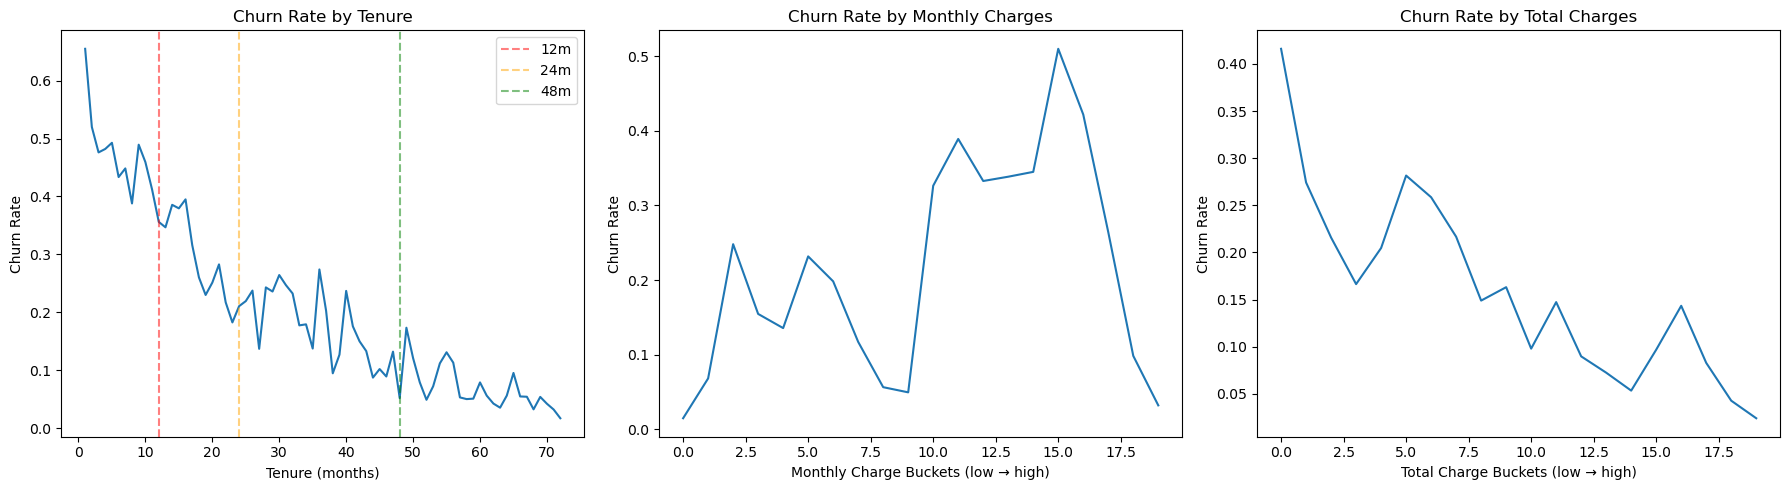

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# tenure vs Churn
train_df = df[df['Churn'].notnull()].copy()
train_df['Churn'] = train_df['Churn'].astype(int)

# 1. Tenure - churn rate per tenure month
tenure_churn = train_df.groupby('tenure')['Churn'].mean()
axes[0].plot(tenure_churn.index, tenure_churn.values)
axes[0].set_title('Churn Rate by Tenure')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Churn Rate')
axes[0].axvline(x=12, color='red', linestyle='--', alpha=0.5, label='12m')
axes[0].axvline(x=24, color='orange', linestyle='--', alpha=0.5, label='24m')
axes[0].axvline(x=48, color='green', linestyle='--', alpha=0.5, label='48m')
axes[0].legend()

# 2. MonthlyCharges - churn rate per charge bucket
train_df['charge_bucket'] = pd.cut(train_df['MonthlyCharges'], bins=20)
charge_churn = train_df.groupby('charge_bucket', observed=True)['Churn'].mean()
axes[1].plot(range(len(charge_churn)), charge_churn.values)
axes[1].set_title('Churn Rate by Monthly Charges')
axes[1].set_xlabel('Monthly Charge Buckets (low → high)')
axes[1].set_ylabel('Churn Rate')

# 3. TotalCharges
train_df['total_bucket'] = pd.cut(train_df['TotalCharges'], bins=20)
total_churn = train_df.groupby('total_bucket', observed=True)['Churn'].mean()
axes[2].plot(range(len(total_churn)), total_churn.values)
axes[2].set_title('Churn Rate by Total Charges')
axes[2].set_xlabel('Total Charge Buckets (low → high)')
axes[2].set_ylabel('Churn Rate')

plt.tight_layout()
plt.show()

In [26]:
# Tenure bins - adjusted boundaries from plot
df['tenure_bin'] = pd.cut(df['tenure'],
    bins=[0, 12, 30, 50, 72],
    labels=[0, 1, 2, 3],
    right=True
).astype(int)

# MonthlyCharges bins - based on churn rate zones
df['monthly_bin'] = pd.cut(df['MonthlyCharges'],
    bins=[0, 35, 65, 85, 120],
    labels=[0, 1, 2, 3],
    right=True
).astype(int)

# avg_monthly ratio
df['avg_monthly'] = df['TotalCharges'] / (df['tenure'] + 1)

# Drop TotalCharges - captured by avg_monthly + tenure
df.drop(['TotalCharges','tenure','MonthlyCharges'], axis=1, inplace=True)

In [28]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
       'Churn', 'hasInternet', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic',
       'InternetService_No', 'tenure_bin', 'monthly_bin', 'avg_monthly'],
      dtype='object')

In [29]:
columns = df.columns.tolist()
for col in columns:
    print(f'{col} : {df[col].unique()}')

gender : [1 0]
SeniorCitizen : [0 1]
Partner : [1 0]
Dependents : [1 0]
PhoneService : [1 0]
MultipleLines : [0 1]
OnlineSecurity : [1 0]
OnlineBackup : [0 1]
DeviceProtection : [1 0]
TechSupport : [1 0]
StreamingTV : [0 1]
StreamingMovies : [0 1]
PaperlessBilling : [1 0]
Churn : [ 0.  1. nan]
hasInternet : [1 0]
PaymentMethod_Credit card (automatic) : [False  True]
PaymentMethod_Electronic check : [False  True]
PaymentMethod_Mailed check : [ True False]
Contract_One year : [ True False]
Contract_Two year : [False  True]
InternetService_Fiber optic : [False  True]
InternetService_No : [False  True]
tenure_bin : [1 3 0 2]
monthly_bin : [1 2 3 0]
avg_monthly : [55.12833333 64.03728814 99.0059322  ... 63.09473684 56.06944444
 99.02407407]


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df[df['Churn'].notnull()][['avg_monthly']])
df['avg_monthly'] = scaler.transform(df[['avg_monthly']])

In [37]:
columns = df.columns.tolist()
for col in columns:
    print(f'{col} : {df[col].unique()}')

gender : [1 0]
SeniorCitizen : [0 1]
Partner : [1 0]
Dependents : [1 0]
PhoneService : [1 0]
MultipleLines : [0 1]
OnlineSecurity : [1 0]
OnlineBackup : [0 1]
DeviceProtection : [1 0]
TechSupport : [1 0]
StreamingTV : [0 1]
StreamingMovies : [0 1]
PaperlessBilling : [1 0]
Churn : [ 0.  1. nan]
hasInternet : [1 0]
PaymentMethod_Credit card (automatic) : [False  True]
PaymentMethod_Electronic check : [False  True]
PaymentMethod_Mailed check : [ True False]
Contract_One year : [ True False]
Contract_Two year : [False  True]
InternetService_Fiber optic : [False  True]
InternetService_No : [False  True]
tenure_bin : [1 3 0 2]
monthly_bin : [1 2 3 0]
avg_monthly : [-0.17412027  0.06830356  1.01984419 ...  0.04265556 -0.14851145
  1.02033785]


In [38]:
y = df[df.Churn.notnull()].pop('Churn')
X = df[df.Churn.notnull()].drop('Churn',axis = 1)
test = df[df['Churn'].isna()].copy().drop('Churn',axis =1)

from sklearn.model_selection import train_test_split

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size = 0.2)


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lr_model = LogisticRegression(
    random_state = 42,
    n_jobs = -1,
    class_weight = 'balanced',
    max_iter = 1000,
    solver='saga',
    C = 0.01
)

lr_model.fit(X_train,y_train)

print(f'Training accuracy is :',roc_auc_score(y_train,lr_model.predict_proba(X_train)[:,1]))
print(f'Testing accuracy is :',roc_auc_score(y_val,lr_model.predict_proba(X_val)[:,1]))

Training accuracy is : 0.9056997700627633
Testing accuracy is : 0.906857392832458


In [47]:
for c in [0.001, 0.01, 0.1, 1.0, 10]:
    lr = LogisticRegression(C=c, solver='saga', 
                            class_weight='balanced', 
                            max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    val_auc = roc_auc_score(y_val, lr.predict_proba(X_val)[:,1])
    print(f'C={c} → Val AUC: {val_auc:.4f}')

C=0.001 → Val AUC: 0.9064
C=0.01 → Val AUC: 0.9069
C=0.1 → Val AUC: 0.9068
C=1.0 → Val AUC: 0.9068
C=10 → Val AUC: 0.9068


In [49]:
predictions = lr_model.predict_proba(test)[:,1]
submission = pd.DataFrame({'id': test.index, 'Churn': predictions})
submission.to_csv('../output/submission_lr.csv', index=False)

# Save model
joblib.dump(lr_model, '../models/lr_model.pkl')

['../models/lr_model.pkl']